# RMSF：700、800、1000 分段独立拟合

各一条 Monomer 轨迹；统一 **1.5–3 μs**、**1 ns** 间隔，每组 **1501 帧**。

ITP 标注的螺旋为 3–37 和 45–92，IDR 为 96–140。据此将端部残基归入相邻螺旋，分为 **1–37、38–44、45–95、96–140**。
每段分别运行 GROMACS `rmsf -res -fit`：**拟合与 RMSF 计算都只选择该段 BB**，参考为各自 `step5_production.tpr` 中的对应片段（不是平均结构）。RMSF 是拟合后相对该段时间平均坐标的波动。

四个面板使用各自的 y 轴范围。该处理去除了片段整体平移/旋转，着重显示片段内部波动；不能用它衡量段间相对运动。
连接区仅 7 个 BB，独立拟合会移除其整体运动；IDR 的独立拟合用于描述尾部内部波动，并不假设其是刚性结构域。

原来 **1–140 BB 全链拟合**的 CSV、XVG、日志、参数和 PNG/PDF 保存在 `whole_chain_fit/`。Rg/e2e 不受本次拟合方式修改影响。


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'Monomer/alhx_700/step5_production.tpr').exists())
BASE = ROOT / 'Analysis/EN_modeltest'
sys.path.insert(0, str(BASE))
import compare_trajectories as analysis
import pandas as pd
import matplotlib.pyplot as plt
KIND = 'RMSF'
OUT = BASE / KIND
RECOMPUTE = False  # True: recompute from the preprocessed trajectories


## 数据

默认读取已计算数据；设 `RECOMPUTE=True` 可重新计算。共享实现见上级目录 `compare_trajectories.py`。Rg/e2e 重算时共用一次轨迹遍历，同时更新两者的数据。

In [2]:
if RECOMPUTE or not (OUT / 'data/rmsf.csv').exists():
    analysis.compute_rmsf()
data = pd.read_csv(OUT / 'data/rmsf.csv')
print(data.groupby('condition', sort=False).size().to_string())
print(pd.read_csv(OUT / 'data/segment_summary.csv').to_string(index=False))

# Descriptive comparison with the archived whole-chain fit, using the same residues.
whole = pd.read_csv(OUT / 'whole_chain_fit/data/rmsf.csv')
comparison = data.merge(whole, on=['condition', 'residue'], suffixes=('_segment', '_whole'), validate='one_to_one')
comparison = comparison.groupby(['condition', 'segment'], sort=False).agg(
    segment_fit_mean_nm=('rmsf_nm_segment', 'mean'),
    whole_fit_mean_nm=('rmsf_nm_whole', 'mean')).reset_index()
comparison.to_csv(OUT / 'data/whole_vs_segment_summary.csv', index=False)
print(comparison.to_string(index=False))


condition
alhx_700     140
alhx_800     140
alhx_1000    140
condition segment  count     mean    min    max
 alhx_700  helix1     37 0.121835 0.0718 0.3097
 alhx_700  linker      7 0.102371 0.0607 0.1619
 alhx_700  helix2     51 0.165147 0.1043 0.4105
 alhx_700    tail     45 1.076124 0.7470 1.9112
 alhx_800  helix1     37 0.118249 0.0711 0.3031
 alhx_800  linker      7 0.093843 0.0526 0.1523
 alhx_800  helix2     51 0.167188 0.1046 0.4253
 alhx_800    tail     45 1.083300 0.7349 2.0608
alhx_1000  helix1     37 0.113557 0.0664 0.2909
alhx_1000  linker      7 0.095271 0.0503 0.1535
alhx_1000  helix2     51 0.158324 0.1005 0.3929
alhx_1000    tail     45 1.116893 0.7545 1.9993
condition segment  segment_fit_mean_nm  whole_fit_mean_nm
 alhx_700  helix1             0.121835           2.199019
 alhx_700  linker             0.102371           1.628971
 alhx_700  helix2             0.165147           1.462812
 alhx_700    tail             1.076124           2.382120
 alhx_800  helix1        

## 对比图

运行后更新当前文件夹的 PNG/PDF；输入路径、文件大小和时间戳、分析参数见 `data/provenance.json`。

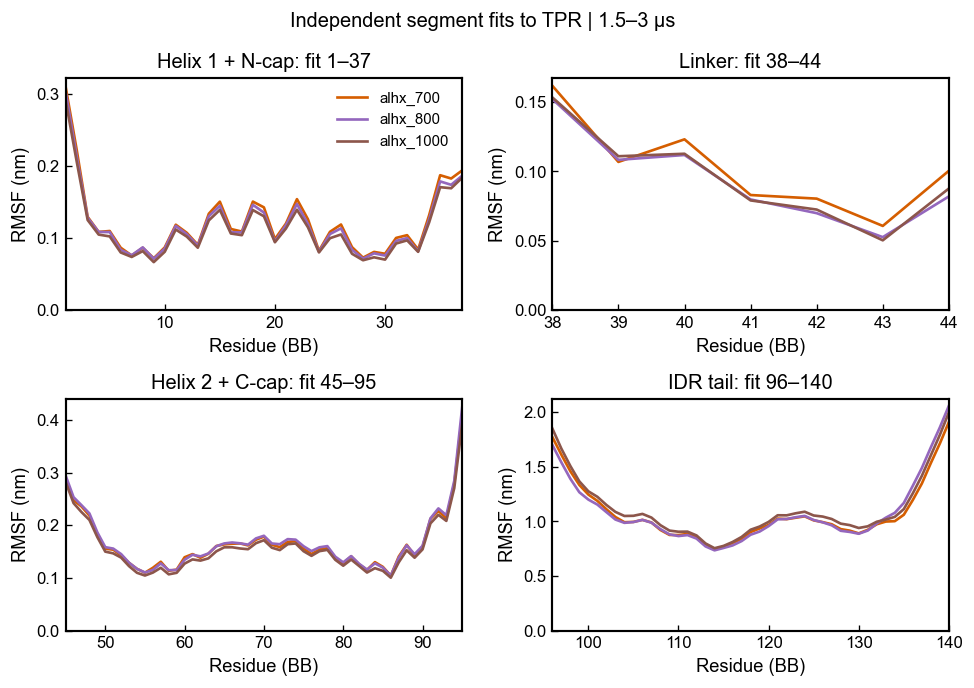

In [3]:
fig = analysis.plot(KIND)
plt.show()


## 当前结果的解读

- 第一段平均逐残基 RMSF：700 / 800 / 1000 = **0.1218 / 0.1182 / 0.1136 nm**。
- 第二段：**0.1651 / 0.1672 / 0.1583 nm**。
- 尾部：**1.0761 / 1.0833 / 1.1169 nm**。

这是各段逐残基 RMSF 的算术平均，不是整段 RMSD。全链拟合时两段螺旋的该均值为 1.4–2.2 nm；分段独立拟合后明显降低，说明片段相对运动对原来的 RMSF 贡献很大。两种拟合的 RMSF 不能直接相减当作可加的运动分解。

1000 的两段螺旋平均内部波动略低，但 700→800→1000 并非两段都单调下降。每组只有一条轨迹、相邻帧相关，这里不把小差异解释为统计显著差异。
